**Table of contents**<a id='toc0_'></a>    
- [Datos](#toc1_)    
  - [Preparación de datos](#toc1_1_)    
  - [Dataset y dataloader](#toc1_2_)    
- [Training loop y modelos](#toc2_)    
- [Flujo de trabajo](#toc3_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

El objetivo es usar **redes neuronales**, sea el método más conveniente o no
(mi propósito es coger unos datos cualesquiera y aplicar los conceptos de la
asignatura).

Este notebook es un ejemplo sencillo, usando **una única capa** variando el número
de neuronas y la función de activación.

Cheat Sheet de pandas: https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf

<b style="background: yellow; color:black">Este notebook no utiliza GPU.</b>

(Me compré una Radeon maldita sea).

# <a id='toc1_'></a>[Datos](#toc0_)

Sin cuenta de Kaggle, mirar [Experimentos/Spaceship Titanic/README.md]()

In [1]:
import kagglehub
kagglehub.login()

In [80]:
path = kagglehub.competition_download('spaceship-titanic', force_download=True)
print("Path to competition files:", path)

100%|██████████| 299k/299k [00:00<00:00, 733kB/s]

Extracting files...
Path to competition files: /home/javier/.cache/kagglehub/competitions/spaceship-titanic


In [81]:
import pandas as pd
import os

print(os.listdir(path))

df_test = pd.read_csv(path + "/test.csv")
df_train = pd.read_csv(path + "/train.csv")

display(df_train.head())

print("Número de filas: ", len(df_train))
df_train.info()

['sample_submission.csv', 'test.csv', 'train.csv']


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


Número de filas:  8693
<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB


- La columna `PassengerId` solo servirá para contrastar los aciertos. Ahí se queda.
- La columna `HomePlanet` solo tiene 4 valores, también a discretizar.
- La columna `Cabin` parecería conveniente dividirla en otras 3 columnas.
- La columna `Destination` solo tiene 4 valores, así que se podría discretizar.
- La columna `CryoSleep`: columna booleana, a convertir en `0` y `1`.
- Columna `VIP`: igual que con `CryoSleep`.
- La columna `Name`: a eliminarla. El número de filas es demasiado poco como para
  inferir algo con el nombre. **Sin embargo**, sí sería interesante sacar el sexo
  más probable en función del nombre (cosa que no voy a hacer de momento).

In [82]:
print("Nº valores en Destination: ", len(df_train["Destination"].unique()))
print("Nº valores en HomePlanet: ", len(df_train["HomePlanet"].unique()))
print("Nº valores en Name: ", len(df_train["Name"].unique()))

Nº valores en Destination:  4
Nº valores en HomePlanet:  4
Nº valores en Name:  8474


In [83]:
display(df_train.isna().sum())
# df_train.info()
print("Filas con valores nulos: ", df_train.isna().any(axis=1).sum())
print(
    "Filas con valores nulos: ",
    df_train.isna().any(axis=1).sum() / len(df_train) * 100,
    "%",
)

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

Filas con valores nulos:  2087
Filas con valores nulos:  24.007822385827676 %


Hay un 24% de filas con valores nulos, son demasiadas como para quitarlas. Habrá que ir viendo alternativas.

Una alternativa es asociar a los valores NaN un número que no aparezca (y se aleje razonablemente) de los otros valores de la columna. Como todos los valores son positivos,
decido cambiar los NaN por **valores negativos**. Y para que no tenga ni demasiado poco
ni demasiado peso, decido asignarle la media en negativo.

In [84]:
(df_train.select_dtypes(include=["float", "int"]) < 0).values.sum()

np.int64(0)

## <a id='toc1_1_'></a>[Preparación de datos](#toc0_)

Con todo lo anterior en mente, el procesado de datos se encuentra `DataProcessor`.
`process_data_1()` aplica los cambios a un dataframe.

Tablas finales: `df_train`, `df_test`.

La columna `name` no sirve para nada (por ahora. Podrían hacerse cosas, como usar
diccionarios y sacar el sexo más probable, pero ahora no lo haré).

In [95]:
import DataProcessor
from DataProcessor import process_data_1
# import importlib # Porque lo recargo varias veces para corregir errores
# importlib.reload(DataProcessor)

df_train_processed, input_columns = process_data_1(df_train)
df_train_processed.dtypes

PassengerId         str
HomePlanet      float64
CryoSleep       float64
Cabin               str
Destination     float64
Age             float64
VIP             float64
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Transported     float64
Cabin_1         float64
Cabin_2         float64
Cabin_3         float64
dtype: object

In [96]:
print("Nº valores nulos: ", df_train_processed[input_columns].isna().sum().sum())
df_train_processed[input_columns].dtypes == float
# Ya está listo el dataframe

Nº valores nulos:  0


HomePlanet      True
CryoSleep       True
Destination     True
Age             True
VIP             True
RoomService     True
FoodCourt       True
ShoppingMall    True
Spa             True
VRDeck          True
Cabin_1         True
Cabin_2         True
Cabin_3         True
dtype: bool

## <a id='toc1_2_'></a>[Dataset y dataloader](#toc0_)

**Es inportante que las columnas estén ordenadas aflabéticamente**. Se pueden ver
en el atributo `input_columns` del Dataset.

Muy importante la dimensionalidad del tensor en `__getitem()__`.

Aquí ya **divido `df_train`** en un dataframe para entrenamiento y otro para testing.
El dataframe `df_test` en realidad es para subir las predicciones sobre ese, no sirve
para medir el accuracy (puesto que dicho dataframe no tiene etiqueta de salida).

In [97]:
hyperparameters_1 = {
  'batch_size': 1
}

In [98]:
import importlib
import torch
from torch.utils.data import DataLoader
from DataProcessor import SpaceshipDatset_1
from torch.utils.data import random_split

importlib.reload(DataProcessor)  # Porque lo recargo varias veces para corregir errores

dataset_1 = SpaceshipDatset_1(df_train_processed, input_columns)

print('"Columnas": ', input_columns)
print("Valores idx=1 y valor target: ", dataset_1[1])

# 80% de datos para train, 20% para test
train_dataset_1, test_dataset_1 = random_split(
	dataset_1,
 	[int(0.8 * len(dataset_1)), len(dataset_1) - int(0.8 * len(dataset_1))]
)

train_dataloader_1 = DataLoader(train_dataset_1, batch_size=hyperparameters_1["batch_size"])
test_dataloader_1 = DataLoader(test_dataset_1, batch_size=hyperparameters_1["batch_size"])

"Columnas":  ['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Cabin_1', 'Cabin_2', 'Cabin_3']
Valores idx=1 y valor target:  (tensor([ 24.,   5.,   0.,   0.,  -1.,   1.,   9.,   2., 109.,  25., 549.,   1.,
         44.]), np.float64(1.0))


# <a id='toc2_'></a>[Training loop y modelos](#toc0_)

In [99]:
from tqdm import tqdm

# Código del notebook de la asignatura (mirar README)
def learning_loop_1(dataloader, model, epochs, loss_fn, learning_rate, optimizer):
    epoch_loss_list = []

    opt = optimizer(model.parameters(), lr=learning_rate)

    for epoch in tqdm(range(epochs), desc="epoch:"):
        step_loss_list = []
        for x_true, y_true in dataloader:
            y_pred = model(x_true)  # Forward
            opt.zero_grad()
            loss = loss_fn(y_pred, y_true)
            loss.backward()  # Backward
            step_loss_list.append(loss.clone().detach())
            opt.step()
        epoch_loss_list.append(torch.tensor(step_loss_list).mean())

    return model, epoch_loss_list


# Entrenamiento de un epoch por PyTorch:
def train_one_epoch(epoch_index, model, loss_fn, tb_writer, training_loader, optimizer):
    running_loss = 0.0
    last_loss = 0.0

    # Here, we use enumerate(training_loader) instead of
    # iter(training_loader) so that we can track the batch
    # index and do some intra-epoch reporting
    for i, data in enumerate(training_loader):
        # Every data instance is an input + label pair
        inputs, labels = data

        # Zero your gradients for every batch!
        optimizer.zero_grad()

        # Make predictions for this batch
        outputs = model(inputs)

        # Compute the loss and its gradients
        loss = loss_fn(outputs, labels)
        loss.backward()

        # Adjust learning weights
        optimizer.step()

        # Gather data and report
        running_loss += loss.item()
        if i % 1000 == 999:
            last_loss = running_loss / 1000  # loss per batch
            print(f"  batch {i + 1} loss: {last_loss}")
            tb_x = epoch_index * len(training_loader) + i + 1
            tb_writer.add_scalar("Loss/train", last_loss, tb_x)
            running_loss = 0.0

    return last_loss

 ## Modelos

Como la salida está entre 0 y 1, la función de la última capa será la sigmoide
en todos los modelos.

### Perceptrones

Como esto es por experimentar simplemente, decido usar algunos modelos muy simples
cambiando únicamente la función de activación de la capa oculta. **Son perceptrones
simples, vaya**.

Recordar que aunque en el código se vea "una capa lineal, y luego una ReLU",
una neurona tiene esas dos estapas: combinación lineal y función de activación.

**Función de error**: error absoluto (L1), puesto que el cuadrático penaliza menos
cuando los valores son menores que 1. (O entre -1 y 1).

In [100]:
# 13 valores de entrada. len(dataset_1[1][0]) = 13
model_1 = torch.nn.Sequential(
	torch.nn.Linear(13, 13),
	torch.nn.ReLU(),
	torch.nn.Linear(13, 1),
	torch.nn.Sigmoid()
)

model_2 = torch.nn.Sequential(
	torch.nn.Linear(13, 13),
	torch.nn.LeakyReLU(),
 	torch.nn.Linear(13, 1),
	torch.nn.Sigmoid()
)

model_3 = torch.nn.Sequential(
	torch.nn.Linear(13, 13),
	torch.nn.Tanh(),
 	torch.nn.Linear(13, 1),
	torch.nn.Sigmoid()
)

model_4 = torch.nn.Sequential(
	torch.nn.Linear(13, 13),
	torch.nn.Sigmoid(),
 	torch.nn.Linear(13, 1),
	torch.nn.Sigmoid()
)

Como no tengo CUDA y estoy usando el procesador... uso pocas `epochs`. Sería aún mejor usar datos para validación, pero de momento lo mantengo simple.

In [102]:
learning_rate = 1e-2
epochs = 10
loss_fn = torch.nn.L1Loss()
optimizer = torch.optim.SGD

model_1, epoch_lost_list_1 = learning_loop_1(
    train_dataloader_1, model_1, epochs, loss_fn, learning_rate, optimizer
)

model_2, epoch_lost_list_2 = learning_loop_1(
    train_dataloader_1, model_2, epochs, loss_fn, learning_rate, optimizer
)

model_3, epoch_lost_list_3 = learning_loop_1(
    train_dataloader_1, model_3, epochs, loss_fn, learning_rate, optimizer
)

model_4, epoch_lost_list_4 = learning_loop_1(
    train_dataloader_1, model_4, epochs, loss_fn, learning_rate, optimizer
)

epoch::   0%|          | 0/10 [00:00<?, ?it/s]/home/javier/Desktop/Programacion-para-la-Inteligencia-Artificial/.venv/lib/python3.12/site-packages/torch/nn/modules/loss.py:133: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)
epoch:: 100%|██████████| 10/10 [00:41<00:00,  4.14s/it]


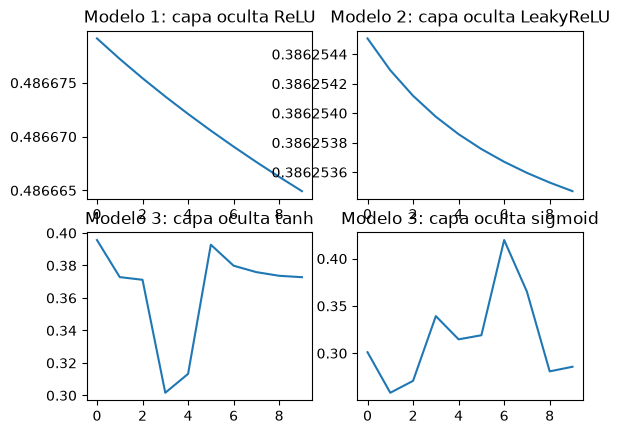

In [107]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2,2)

axs[0,0].plot(epoch_lost_list_1)
axs[0,0].set_title("Modelo 1: capa oculta ReLU")
axs[0,0].ticklabel_format(axis='y', style='plain', useOffset=False)

axs[0,1].plot(epoch_lost_list_2)
axs[0,1].set_title("Modelo 2: capa oculta LeakyReLU")
axs[0,1].ticklabel_format(axis='y', style='plain', useOffset=False)

axs[1,0].plot(epoch_lost_list_3)
axs[1,0].set_title("Modelo 3: capa oculta tanh")

axs[1,1].plot(epoch_lost_list_4)
axs[1,1].set_title("Modelo 3: capa oculta sigmoid")

plt.show()

El `batch` es de tamaño 1, así que es de esperar que sea tan susceptible al ruido y no sea
tan estable. Además de usar pocas épocas y no usar momentum...

Sí que se puede apreciar que ReLU y LeakyReLU se comportan parecido y son menos caóticas, o eso parece (porque ni he usado mucho entrenamiento, ni son datos de validación sino los de entrenamiento).

<b> Finalmente: considero que acierta si le asocia un valor >= 0.5 (Transported = True)</b>

In [ ]:
correct = [0, 0, 0, 0] # Nº Aciertos por modelo
total = 0
with torch.no_grad():
    for X, Y in test_dataloader_1:
        total += 1
        if Y == 1:
            if model_1(X) >= 0.5:
                correct[0] += 1
            if model_2(X) >= 0.5:
                correct[1] += 1
            if model_3(X) >= 0.5:
                correct[2] += 1
            if model_4(X) >= 0.5:
                correct[3] += 1
        if Y == 0:
            if model_1(X) < 0.5:
                correct[0] += 1
            if model_2(X) < 0.5:
                correct[1] += 1
            if model_3(X) < 0.5:
                correct[2] += 1
            if model_4(X) < 0.5:
                correct[3] += 1
                
# accuracy = correct / total
# print(f"Accuracy: {accuracy:.4f}")
print("Accuracy modelo 1: ", correct[0]/total)
print("Accuracy modelo 2: ", correct[1]/total)
print("Accuracy modelo 3: ", correct[2]/total)
print("Accuracy modelo 4: ", correct[3]/total)

Accuracy modelo 1:  0.515813686026452
Accuracy modelo 2:  0.6147211040828062
Accuracy modelo 3:  0.6336975273145485
Accuracy modelo 4:  0.7475560667050029


¿Cómo de bien ha funcionado? Voy a comparar con la frecuencia relativa de `Transported`.
Como hay un $\approx$ 50% de ser transportado, un accuracy mayor que eso no está _tan_.
Un accuracy menor del 50%... simplemente sería mejor poner un número aleatorio...

In [114]:
df_train.Transported.sum() / len(df_train)

np.float64(0.5036236051995858)

# Construyendo el entregable

Uso "test" para dos cosas: comprobar el accuracy contra datos conocidos, y en este caso "test"
es para el entregable en Kaggle. (Usando un dataframe `df_test` que no contiene la columna `Transported`).

In [157]:
df_test_processed, input_columns = process_data_1(df_test, transported_column=False)

predictions = []

with torch.no_grad():
    for i, row in df_test_processed.iterrows():
        X = torch.tensor(list(row[input_columns]))
        predictions.append({
            "PassengerId": row["PassengerId"],
            "Transported": bool(model_4(X) >= 0.5)
        })

df_deliver = pd.DataFrame(predictions)
df_deliver.to_csv("df_deliver.csv", index=False)
df_deliver.head()

,PassengerId,Transported
0,0013_01,False
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


Score conseguido en Kaggle: 0.62730.

Lo que es **extremadamente bajo**, por cierto. Pero era esperable. Aquí se acaba este ejemplo sencillo.